In [ ]:
!pip install -q --upgrade kaggle

In [ ]:
import os
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

print("Kaggle credentials loaded successfully.")

Kaggle credentials loaded successfully.


In [ ]:
!mkdir -p /content/data
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset -p /content/data

Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
microsoft-catsvsdogs-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import zipfile
import os

zip_path = "/content/data/microsoft-catsvsdogs-dataset.zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [ ]:
base_dir = "/content/data/PetImages"

print("Available folders:", os.listdir(base_dir))
print("Cat images:", len(os.listdir(os.path.join(base_dir, "Cat"))))
print("Dog images:", len(os.listdir(os.path.join(base_dir, "Dog"))))

Available folders: ['Dog', 'Cat']
Cat images: 12501
Dog images: 12501


In [ ]:
import os
import tensorflow as tf

dataset_path = "/content/data/PetImages"

bad_files = []

for root, _, files in os.walk(dataset_path):
    for file in files:
        path = os.path.join(root, file)
        try:
            img = tf.io.read_file(path)
            tf.io.decode_image(img)
        except Exception as e:
            print(f"Bad file: {path}")
            print(e)
            bad_files.append(path)

print(f"\nTotal bad files: {len(bad_files)}")

Bad file: /content/data/PetImages/Dog/2494.jpg
{{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Input size should match (header_size + row_size * abs_height) but they differ by 2 [Op:DecodeImage] name: 
Bad file: /content/data/PetImages/Dog/11912.jpg
{{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Number of channels inherent in the image must be 1, 3 or 4, was 2 [Op:DecodeImage] name: 
Bad file: /content/data/PetImages/Dog/9500.jpg
{{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Number of channels inherent in the image must be 1, 3 or 4, was 2 [Op:DecodeImage] name: 
Bad file: /content/data/PetImages/Dog/11233.jpg
{{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Number of channels inherent in the image must be 1, 3 or 4, was 2 [Op:DecodeImage] name: 
Bad file: /content/data/PetImages/Dog/Thumbs.db
{{function_no

In [ ]:
from PIL import Image
import os

dataset_path = "/content/data/PetImages"

for root, _, files in os.walk(dataset_path):
    for file in files:
        path = os.path.join(root, file)
        try:
            img = Image.open(path)
            if img.mode not in ["RGB", "L", "RGBA"]:
                print(f"{path} -> mode: {img.mode}")
        except Exception:
            print(f"Corrupted: {path}")

/content/data/PetImages/Dog/9188.jpg -> mode: P
/content/data/PetImages/Dog/11410.jpg -> mode: P
/content/data/PetImages/Dog/10797.jpg -> mode: P
/content/data/PetImages/Dog/11853.jpg -> mode: P
/content/data/PetImages/Dog/1308.jpg -> mode: P
/content/data/PetImages/Dog/7133.jpg -> mode: P
/content/data/PetImages/Dog/2877.jpg -> mode: P
/content/data/PetImages/Dog/3588.jpg -> mode: P
/content/data/PetImages/Dog/3288.jpg -> mode: P
/content/data/PetImages/Dog/6059.jpg -> mode: P


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


/content/data/PetImages/Dog/11849.jpg -> mode: P
/content/data/PetImages/Dog/1789.jpg -> mode: CMYK
/content/data/PetImages/Dog/6238.jpg -> mode: P
/content/data/PetImages/Dog/10747.jpg -> mode: P
/content/data/PetImages/Dog/8730.jpg -> mode: P
/content/data/PetImages/Dog/3136.jpg -> mode: P
/content/data/PetImages/Dog/7369.jpg -> mode: P
/content/data/PetImages/Dog/10401.jpg -> mode: P
/content/data/PetImages/Dog/7112.jpg -> mode: P
/content/data/PetImages/Dog/6245.jpg -> mode: CMYK
/content/data/PetImages/Dog/5604.jpg -> mode: P
/content/data/PetImages/Dog/5736.jpg -> mode: P
/content/data/PetImages/Dog/7969.jpg -> mode: P
/content/data/PetImages/Dog/1866.jpg -> mode: P
/content/data/PetImages/Dog/4367.jpg -> mode: P
/content/data/PetImages/Dog/7459.jpg -> mode: P
/content/data/PetImages/Dog/1259.jpg -> mode: P
/content/data/PetImages/Dog/9078.jpg -> mode: CMYK
/content/data/PetImages/Dog/6318.jpg -> mode: P
/content/data/PetImages/Dog/2688.jpg -> mode: P
/content/data/PetImages/Dog/

In [ ]:
import os

for file in bad_files:
    os.remove(file)
    print("Deleted:", file)

Deleted: /content/data/PetImages/Dog/2494.jpg
Deleted: /content/data/PetImages/Dog/11912.jpg
Deleted: /content/data/PetImages/Dog/9500.jpg
Deleted: /content/data/PetImages/Dog/11233.jpg
Deleted: /content/data/PetImages/Dog/Thumbs.db
Deleted: /content/data/PetImages/Dog/2317.jpg
Deleted: /content/data/PetImages/Dog/11702.jpg
Deleted: /content/data/PetImages/Cat/4351.jpg
Deleted: /content/data/PetImages/Cat/10404.jpg
Deleted: /content/data/PetImages/Cat/Thumbs.db
Deleted: /content/data/PetImages/Cat/666.jpg


In [ ]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16

In [ ]:
conv_base = VGG16(
    weights='imagenet',
    include_top = False,
    input_shape=(150,150,3)
)

In [ ]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model = Sequential()
model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 16,812,353 (64.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
conv_base.trainable = False

In [ ]:
import tensorflow as tf
from tensorflow import keras

train_ds = keras.utils.image_dataset_from_directory(
    "/content/data/PetImages",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(150, 150),
    batch_size=32
)

validation_ds = keras.utils.image_dataset_from_directory(
    "/content/data/PetImages",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(150, 150),
    batch_size=32
)

Found 24991 files belonging to 2 classes.
Using 19993 files for training.
Found 24991 files belonging to 2 classes.
Using 4998 files for validation.


In [ ]:
train_count = tf.data.experimental.cardinality(train_ds).numpy() * 32
val_count = tf.data.experimental.cardinality(validation_ds).numpy() * 32

print("Approx training images:", train_count)
print("Approx validation images:", val_count)

Approx training images: 20000
Approx validation images: 5024


In [ ]:
import tensorflow as tf

# Normalize
def process(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history = model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 100s 145ms/step - accuracy: 0.8867 - loss: 0.2680 - val_accuracy: 0.8996 - val_loss: 0.2434
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 137ms/step - accuracy: 0.9222 - loss: 0.1907 - val_accuracy: 0.8940 - val_loss: 0.2546
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 129ms/step - accuracy: 0.9352 - loss: 0.1578 - val_accuracy: 0.9068 - val_loss: 0.2335
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 129ms/step - accuracy: 0.9462 - loss: 0.1312 - val_accuracy: 0.9156 - val_loss: 0.2132
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 136ms/step - accuracy: 0.9591 - loss: 0.1024 - val_accuracy: 0.9150 - val_loss: 0.2319
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 129ms/step - accuracy: 0.9635 - loss: 0.0909 - val_accuracy: 0.9132 - val_loss: 0.2484
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 129ms/step - accuracy: 0.9748 - loss: 0.0666 - val_accuracy: 0.9148 - val_loss: 0.2719
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 129ms/step - accuracy: 0.9855 - loss: 

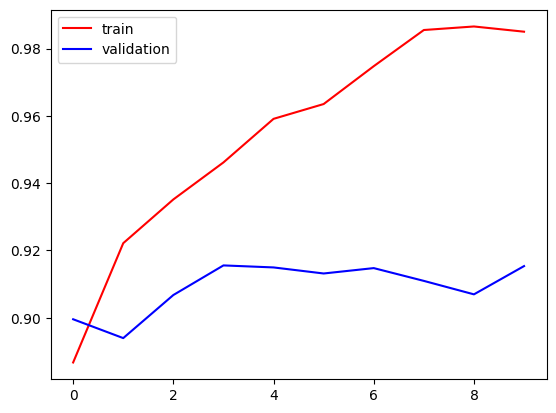

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

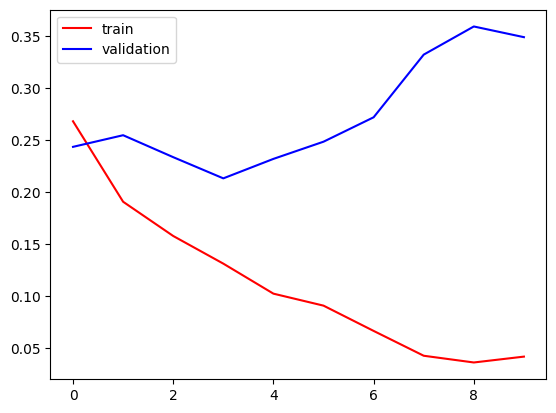

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
import gradio as gr
import tensorflow as tf
import numpy as np

IMG_SIZE = (150, 150)

def predict(img):
    img = img.resize(IMG_SIZE)
    img = np.array(img)

    # Handle grayscale images
    if len(img.shape) == 2:
        img = np.stack([img] * 3, axis=-1)

    # Remove alpha channel
    if img.shape[-1] == 4:
        img = img[:, :, :3]

    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img, verbose=0)

    # Sigmoid output
    if pred.shape[-1] == 1:
        dog = float(pred[0][0])
        cat = 1 - dog
        return {"Cat 🐱": cat, "Dog 🐶": dog}

    # Softmax output
    pred = pred[0]
    return {"Cat 🐱": float(pred[0]), "Dog 🐶": float(pred[1])}

demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="Upload Image"),
    outputs=gr.Label(num_top_classes=2),
    title="Cats 🐱 vs Dogs 🐶 Classifier",
    description="Upload an image of a cat or dog."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1f4e5f9f6868cad5f2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
